In [34]:
# Import various python packages

import iris
import iris.plot as iplt
import iris.quickplot as qplt
import iris.coord_categorisation as icc
from iris.time import PartialDateTime
import iris.analysis

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pandas as pd

import os
import warnings 
import io

import cartopy.io.shapereader as shpreader


from matplotlib.path import Path
import matplotlib.patches as mpatches
import calendar
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.cm import get_cmap
from matplotlib.legend_handler import HandlerBase

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

from scipy.optimize import minimize
from scipy.stats import norm

from scipy.interpolate import PchipInterpolator
from scipy.optimize import differential_evolution

import operator

import pickle
from copy import deepcopy
from pathlib import Path

import csv

import dask
from dask.diagnostics import ProgressBar

import glob


import pandas as pd
from netCDF4 import Dataset


warnings.filterwarnings('ignore') 

In [35]:
import sys
sys.path.append('..')

from Cube_Functions import *
from Plot_Functions import *
from Climate_Functions import *
from Stats_Functions import *
print('Finished loading libraries and functions')

#clean up namespace
del sys

Finished loading libraries and functions


In [36]:

models = [
            'ACCESS-ESM1-5', #*
            'CESM2', #*
            'EC-Earth3',
            #'INM-CM4-8', 
            'IPSL-CM6A-LR', #*
            'MIROC-ES2L', #*
            'MPI-ESM1-2-LR',
            'MRI-ESM2-0',
            'NESM3', #*
            #'NorESM1-F',
            'NorESM2-LM',
            ]

#to add



#############################################################
#Code has been updated to hugely shrink the size of the cubes stored in the dictionaries.
#I need to test it when I can get back on the the jasmin storage, as I need to reload the data to test. 
#Adding MMM to the dictionaries is not working at the moment, due to the cube size
#A workaround is to find another way to add the MMM.
#It was working before, so could just try doing it overnight or something like that
#############################################################

control = 'piControl'
paleo = 'midHolocene' #set paleo2 to None to not use it, or set it to a string to use it (e.g. 'midHolocene'). Analysis still runs on paleo, but paleo2 data is loaded for comparison and plotting.



root_path = '/gws/ssde/j25b/pmip4/vol1/public/matt/data/' #'/gws/nopw/j04/pmip4_vol1/public/matt/data/'

energy_var_dict = {
    'rsds': 1,
    'rsus': -1,
    'rlds': 1,
    'rlus': -1,
    'hfls': -1,
    'hfss': -1
}



energy_vars = list(energy_var_dict.keys())
ice_vars = ['siconc']



var_list = ice_vars + energy_vars 
sia_crossing = None   #Set to a number to use an absolute value for the crossing point, or set to None to use the crossing point determined by the paleo siconc time series.


season = 'Summer'

if season == 'Winter':
    paleo_month = 'Mar'
    paleo2_month = 'Mar'
    transient_month = 'Mar'
    control_month = 'Mar'
elif season == 'Summer':
    paleo_month = 'Aug'
    paleo2_month = 'Sep'
    transient_month = 'Sep'
    control_month = 'Sep'

# Climatology plot settings
x = np.array([15, 45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345])
m = np.arange(12)
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

paper_colours = {
    "lig127k":              "#077907",
    "lig127k Crossing":           "#2EDF8C",
    "midHolocene":              "#AA3377",
    "midHolocene Crossing":           "#EE6677",
    "piControl": "black",
    "total_energy": "#D62E33",  # muted red
    "cs_downwelling_energy": "#D62E33",  # muted red
    "sigrowth":         "#009E73",  # bluish green
    "tos":                    "#0072B2",  # strong blue
}




In [37]:
#Plotting settings

plot_path = '/home/users/matt/FutureComparisons/Figures/'

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
#     "font.size": 8,
#     "axes.labelsize": 8,
#     "axes.titlesize": 8,
#     "xtick.labelsize": 7,
#     "ytick.labelsize": 7,
#     "legend.fontsize": 6.5,
#     "pdf.fonttype": 42,
#     "ps.fonttype": 42,
#     "axes.linewidth": 0.7,
#     "xtick.major.width": 0.7,
#     "ytick.major.width": 0.7,
#     "xtick.major.size": 3,
#     "ytick.major.size": 3,
})

In [38]:
#Define region

con = iris.Constraint(latitude=lambda lat: 60 <= lat <= 90)

time_con = iris.Constraint(year=lambda y:np.logical_and(y>=2035,y<2045))  #time_constraint. Not used anywhere yet.

ocean_shp_reader = shpreader.Reader(shpreader.natural_earth(resolution="110m", category="physical", name="ocean"))
ocean_list = []
for ocean in ocean_shp_reader.records():
    ocean_list.append(ocean.geometry)
ocean_shp = ocean_list[1]

shape = ocean_shp

In [39]:



def check_required_files(
    models,
    experiments,
    var_list,
    root_path,
    check_openable=True,
):
    """
    Check that all files required by the analysis exist.

    If check_openable=True, also checks that each file:
      1. can be opened as NetCDF; and
      2. contains the expected variable.
    """
    records = []

    for model in models:
        for experiment in experiments:
            if experiment is None:
                continue

            for var in var_list:
                # Match the path logic used in get_cube_dict()
                if model == "EC-Earth3" and experiment == "piControl":
                    regrid_label = "regrid"
                else:
                    regrid_label = "cdo"

                path_pattern = create_path(
                    model,
                    experiment,
                    var,
                    root_path,
                    regrid_label=regrid_label,
                )

                matching_files = sorted(
                                        glob.glob(os.path.expanduser(os.fspath(path_pattern)))
                                    )

                if not matching_files:
                    records.append({
                        "model": model,
                        "experiment": experiment,
                        "variable": var,
                        "file": path_pattern,
                        "status": "MISSING",
                        "error": "",
                    })
                    continue

                for filename in matching_files:
                    status = "OK"
                    error = ""

                    if check_openable:
                        try:
                            with Dataset(filename, mode="r") as dataset:
                                if var not in dataset.variables:
                                    status = "VARIABLE MISSING"
                                    error = (
                                        f"Expected {var!r}; variables include: "
                                        f"{list(dataset.variables)}"
                                    )
                        except Exception as exc:
                            status = "UNREADABLE"
                            error = f"{type(exc).__name__}: {exc}"

                    records.append({
                        "model": model,
                        "experiment": experiment,
                        "variable": var,
                        "file": filename,
                        "status": status,
                        "error": error,
                    })

    return pd.DataFrame(records)

In [40]:
file_check = check_required_files(
    models=models,
    experiments=[control, paleo],
    var_list=var_list,
    root_path=root_path,
    check_openable=True,
)

problems = file_check[file_check["status"] != "OK"]

if problems.empty:
    print(f"All {len(file_check)} required files are present and readable.")
else:
    print(
        f"{len(problems)} missing, unreadable, or otherwise unsuitable "
        "file(s) found:"
    )
    display(
        problems[
            ["model", "experiment", "variable", "status", "file", "error"]
        ]
    )

All 126 required files are present and readable.


In [41]:
#some data stored as cubes, some as arrays. This clears it up
def as_array(x):
    if isinstance(x, iris.cube.Cube):
        return np.asarray(x.core_data())
    return np.asarray(x)

In [42]:
def keep_full_years(cube, time_coord_name='time'):
    """
    Return a cube containing only complete calendar years:
    exactly one of each month Jan..Dec.

    Parameters
    ----------
    cube : iris.cube.Cube
        Input cube with a time coordinate.
    time_coord_name : str, optional
        Name of the time coordinate.

    Returns
    -------
    iris.cube.Cube
        Cube containing only full years.
    """
    time_coord = cube.coord(time_coord_name)
    datetimes = time_coord.units.num2date(time_coord.points)

    years = np.array([dt.year for dt in datetimes])
    months = np.array([dt.month for dt in datetimes])

    full_years = []

    for year in np.unique(years):
        year_months = months[years == year]

        # Require exactly 12 points and exactly months 1..12
        if len(year_months) == 12 and np.array_equal(np.sort(year_months), np.arange(1, 13)):
            full_years.append(year)

    full_years = np.array(full_years)

    if len(full_years) == 0:
        raise ValueError("No complete years found in cube.")

    mask = np.isin(years, full_years)

    return cube[mask]

In [43]:
def realise_cube(cube, scheduler="single-threaded", show_progress=True):
    """
    Return a copy of an Iris cube with realised, non-lazy data.

    This prevents small-looking derived cubes from retaining large Dask graphs
    back to the original source data.
    """
    if not cube.has_lazy_data():
        return cube.copy()

    arr = cube.core_data()

    with dask.config.set(scheduler=scheduler):
        if show_progress:
            with ProgressBar():
                data = arr.compute()
        else:
            data = arr.compute()

    return cube.copy(data=data)

In [44]:

def get_cube_dict(model, experiment, var_list, root_path, con, shape):
    cube_dict = {}
    print(f'Loading cubes', end='...')
    for var in var_list:
        print(f'{var}', end='...')
        if model == 'EC-Earth3' and experiment == 'piControl':
            regrid_label = 'regrid'
        else:
            regrid_label = 'cdo'
        path = create_path(model, experiment, var, root_path, regrid_label=regrid_label)
        cube = get_cube(path, var, con, shape=shape)
        #need to trim incomplete years from start and end
        #trimmed_cube = keep_full_years(cube)
        #cube_dict[var] = trimmed_cube
        cube_dict[var] = cube
    print('Done.')
    return cube_dict

In [45]:

def get_ts_dict_from_cube_dict(
    cube_dict,
    var_list,
    energy_var_dict,
    realise=True,
    scheduler="single-threaded",
    show_progress=True,
):
    ts_dict = {}
    energy_vars = list(energy_var_dict.keys())

    print("Calculating time series for", end="...")

    for var in var_list:
        print(f"{var}", end="...")

        cube = cube_dict[var]

        if var == "siconc" or var == "clt":
            analysis = "sum"
        else:
            analysis = "mean"

        if var in energy_vars:
            multiplier = energy_var_dict[var]
        else:
            multiplier = 1

        area_weights = iris.analysis.cartography.area_weights(cube)
        op = get_iris_op(analysis)

        timeseries = cube.collapsed(
            ["latitude", "longitude"],
            op,
            weights=area_weights,
        )

        timeseries = timeseries * multiplier

        if realise:
            print("realising", end="...")
            timeseries = realise_cube(
                timeseries,
                scheduler=scheduler,
                show_progress=show_progress,
            )

        ts_dict[var] = timeseries

    print("Done.")
    return ts_dict

In [46]:

def get_clim_dict_from_ts_dict(
    ts_dict,
    realise=True,
    scheduler="single-threaded",
    show_progress=True,
):
    var_list = list(ts_dict.keys())

    clim_dict = {}

    print("Calculating climatology for", end="...")

    for var in var_list:
        print(f"{var}", end="...")

        timeseries = ts_dict[var]

        op = get_iris_op("mean")

        clim = timeseries.aggregated_by("month", op)

        if realise:
            print("realising", end="...")
            clim = realise_cube(
                clim,
                scheduler=scheduler,
                show_progress=show_progress,
            )

        clim_dict[var] = clim

    print("Done.")
    return clim_dict

In [47]:
def calculate_anomalies(experiment_ts_dict, control_clim_dict = None):    
    experiment_anom_ts_dict = {}
    print(f'Calculating anomalies for', end='...')
    for var, ts in experiment_ts_dict.items():
        print(f'{var}',end="...")
        if control_clim_dict is None:
            #take first 10 years as control climatology
            clim = ts[:120].aggregated_by('month', iris.analysis.MEAN)
        else:
            clim = control_clim_dict[var]
        clim_data = clim.data
        ts_months = ts.coord("month_number").points
        
        month_index = ts_months.astype(int) - 1

        anomalies = ts.copy()
        anomalies.data = ts.data - clim_data[month_index]

        experiment_anom_ts_dict[var] = anomalies
    print('Done.')
    return experiment_anom_ts_dict

In [48]:
#Create dictionaries from data stored in the netcdf files

control_big_dict = {}
paleo_big_dict = {}


for model in models:
  print(f'------------------Processing {model} {control}------------------')
  control_cube_dict = get_cube_dict(model, control, var_list, root_path, con, shape)
  control_ts_dict = get_ts_dict_from_cube_dict(control_cube_dict, var_list, energy_var_dict)
  control_clim_dict = get_clim_dict_from_ts_dict(control_ts_dict)

  control_big_dict[model] = {'cubes': control_cube_dict, 'ts': control_ts_dict, 'clim': control_clim_dict}
  

  print(f'------------------Processing {model} {paleo}------------------')
  paleo_cube_dict = get_cube_dict(model, paleo, var_list, root_path, con, shape)
  paleo_ts_dict = get_ts_dict_from_cube_dict(paleo_cube_dict, var_list, energy_var_dict)
  paleo_clim_dict = get_clim_dict_from_ts_dict(paleo_ts_dict)
  paleo_anom_ts_dict = calculate_anomalies(paleo_ts_dict, control_clim_dict)
  paleo_anom_clim_dict = get_clim_dict_from_ts_dict(paleo_anom_ts_dict)

  paleo_big_dict[model] = {'cubes': paleo_cube_dict, 
                          'ts': paleo_ts_dict, 
                          'clim': paleo_clim_dict,
                          'anom_ts': paleo_anom_ts_dict,
                          'anom_clim': paleo_anom_clim_dict,
                          }


------------------Processing ACCESS-ESM1-5 piControl------------------
Loading cubes...siconc...rsds...rsus...rlds...rlus...hfls...hfss...Done.
[########################################] | 100% Completed | 5.55 sms
[########################################] | 100% Completed | 4.53 sms
[########################################] | 100% Completed | 5.23 sms
[########################################] | 100% Completed | 4.13 sms
[########################################] | 100% Completed | 4.22 sms
[########################################] | 100% Completed | 4.54 sms
[########################################] | 100% Completed | 4.72 sms
Done.
Calculating climatology for...siconc...realising...rsds...realising...rsus...realising...rlds...realising...rlus...realising...hfls...realising...hfss...realising...Done.
------------------Processing ACCESS-ESM1-5 midHolocene------------------
Loading cubes...siconc...rsds...rsus...rlds...rlus...hfls...hfss...Done.
[###################################

In [49]:
#create total energy budget variable and add to big dicts

for big_dict in [control_big_dict, paleo_big_dict]:
    for model in models:
        print(f'Calculating total energy budget for {model} and adding to big dict')
        cube_dict = big_dict[model]['cubes']
        rsds_cube = cube_dict['rsds']
        rsus_cube = cube_dict['rsus']
        rlds_cube = cube_dict['rlds']
        rlus_cube = cube_dict['rlus']
        hfls_cube = cube_dict['hfls']
        hfss_cube = cube_dict['hfss']


        total_energy_cube = (rsds_cube - rsus_cube) + (rlds_cube - rlus_cube) - hfls_cube - hfss_cube
        downwelling_energy = rsds_cube + rlds_cube

        big_dict[model]['cubes']['total_energy'] = total_energy_cube
        big_dict[model]['cubes']['downwelling_energy'] = downwelling_energy

        area_weights = iris.analysis.cartography.area_weights(total_energy_cube)
        total_energy_ts = total_energy_cube.collapsed(['latitude', 'longitude'], iris.analysis.MEAN, weights=area_weights)
        big_dict[model]['ts']['total_energy'] = total_energy_ts

        area_weights = iris.analysis.cartography.area_weights(downwelling_energy)
        downwelling_energy_ts = downwelling_energy.collapsed(['latitude', 'longitude'], iris.analysis.MEAN, weights=area_weights)
        big_dict[model]['ts']['downwelling_energy'] = downwelling_energy_ts

        total_energy_clim = total_energy_ts.aggregated_by('month', iris.analysis.MEAN)
        big_dict[model]['clim']['total_energy'] = total_energy_clim

        
        downwelling_energy_clim = downwelling_energy_ts.aggregated_by('month', iris.analysis.MEAN)
        big_dict[model]['clim']['downwelling_energy'] = downwelling_energy_clim

        if 'anom_clim' in big_dict[model].keys():
            control_total_energy_clim = control_big_dict[model]['clim']['total_energy']
            total_energy_anom_clim = total_energy_clim.copy()
            total_energy_anom_clim.data = total_energy_clim.data - control_total_energy_clim.data
            big_dict[model]['anom_clim']['total_energy'] = total_energy_anom_clim

            control_total_energy_ts = control_big_dict[model]['ts']['total_energy']
            total_energy_anom_ts = total_energy_ts.copy()
            ts_months = total_energy_ts.coord("month_number").points
            month_index = ts_months.astype(int) - 1
            total_energy_anom_ts.data = total_energy_ts.data - control_total_energy_ts.data[month_index]
            big_dict[model]['anom_ts']['total_energy'] = total_energy_anom_ts

            control_downwelling_energy_clim = control_big_dict[model]['clim']['downwelling_energy']
            downwelling_energy_anom_clim = downwelling_energy_clim.copy()
            downwelling_energy_anom_clim.data = downwelling_energy_clim.data - control_downwelling_energy_clim.data
            big_dict[model]['anom_clim']['downwelling_energy'] = downwelling_energy_anom_clim

            control_downwelling_energy_ts = control_big_dict[model]['ts']['downwelling_energy']
            downwelling_energy_anom_ts = downwelling_energy_ts.copy()
            ts_months = downwelling_energy_ts.coord("month_number").points
            month_index = ts_months.astype(int) - 1
            downwelling_energy_anom_ts.data = downwelling_energy_ts.data - control_downwelling_energy_ts.data[month_index]
            big_dict[model]['anom_ts']['downwelling_energy'] = downwelling_energy_anom_ts

Calculating total energy budget for ACCESS-ESM1-5 and adding to big dict
Calculating total energy budget for CESM2 and adding to big dict
Calculating total energy budget for EC-Earth3 and adding to big dict
Calculating total energy budget for IPSL-CM6A-LR and adding to big dict
Calculating total energy budget for MIROC-ES2L and adding to big dict
Calculating total energy budget for MPI-ESM1-2-LR and adding to big dict
Calculating total energy budget for MRI-ESM2-0 and adding to big dict
Calculating total energy budget for NESM3 and adding to big dict
Calculating total energy budget for NorESM2-LM and adding to big dict
Calculating total energy budget for ACCESS-ESM1-5 and adding to big dict
Calculating total energy budget for CESM2 and adding to big dict
Calculating total energy budget for EC-Earth3 and adding to big dict
Calculating total energy budget for IPSL-CM6A-LR and adding to big dict
Calculating total energy budget for MIROC-ES2L and adding to big dict
Calculating total energy

In [50]:
def add_mmm_to_big_dict(big_dict):
    big_dict['MMM'] = {'clim': {}, 'anom_clim': {}}

    for var_type in ['clim', 'anom_clim']:
        if var_type == 'anom_clim' and big_dict == control_big_dict:
            pass
        else:
            for var in big_dict[models[0]][var_type].keys():
                print(f'Calculating MMM for {var_type} {var}')
                mmm = np.zeros(12)
                for model in models:
                    mmm += as_array(big_dict[model][var_type][var])
                    # try:
                    #     mmm += np.asarray(big_dict[model][var_type][var].core_data())
                    # except:
                    #     mmm += np.asarray(big_dict[model][var_type][var])
                mmm /= len(models)
                big_dict['MMM'][var_type][var] = mmm





In [51]:
print('Adding MMM to absolute climatologies', end ='...')

print(control, end='...')
add_mmm_to_big_dict(control_big_dict)

print(paleo, end='...')
add_mmm_to_big_dict(paleo_big_dict)


Adding MMM to absolute climatologies...piControl...Calculating MMM for clim siconc
Calculating MMM for clim rsds
Calculating MMM for clim rsus
Calculating MMM for clim rlds
Calculating MMM for clim rlus
Calculating MMM for clim hfls
Calculating MMM for clim hfss
Calculating MMM for clim total_energy
Calculating MMM for clim downwelling_energy
midHolocene...Calculating MMM for clim siconc
Calculating MMM for clim rsds
Calculating MMM for clim rsus
Calculating MMM for clim rlds
Calculating MMM for clim rlus
Calculating MMM for clim hfls
Calculating MMM for clim hfss
Calculating MMM for clim total_energy
Calculating MMM for clim downwelling_energy
Calculating MMM for anom_clim siconc
Calculating MMM for anom_clim rsds
Calculating MMM for anom_clim rsus
Calculating MMM for anom_clim rlds
Calculating MMM for anom_clim rlus
Calculating MMM for anom_clim hfls
Calculating MMM for anom_clim hfss
Calculating MMM for anom_clim total_energy
Calculating MMM for anom_clim downwelling_energy


In [52]:

def skewed_gaussian_month_weights(mu, sigma, skew, kurt=2, x=None):
    """
    Circular Gaussian month weights with damped skew.

    sigma controls the overall width.
    Large sigma -> nearly uniform weights, regardless of skew.
    """
    if x is None:
        x = np.arange(1, 13)

    if sigma <= 0:
        return None

    # signed circular month difference in [-6, 6)
    d = (x - mu + 6) % 12 - 6
    
    # Gaussian envelope
    g = np.exp(-0.5 * np.abs(d / sigma) ** kurt)

    # Stronger damping: skew vanishes as sigma becomes large
    skew_damping = 1 / (1 + (sigma / 6) ** 2)
    effective_skew = skew #* skew_damping  #remove the skew damping for now. It is not needed for the level of std dev we are get, and just adds complexity

    theta = 2 * np.pi * d / 12.0
    s = np.exp(effective_skew * np.sin(theta))

    w = g * s

    if np.any(~np.isfinite(w)) or np.isclose(w.sum(), 0):
        return None

    return w / w.sum()



In [53]:
anom_big_dict_list = [paleo_big_dict]
anom_big_dict_names = [paleo]

energy_for_analysis = 'total_energy'

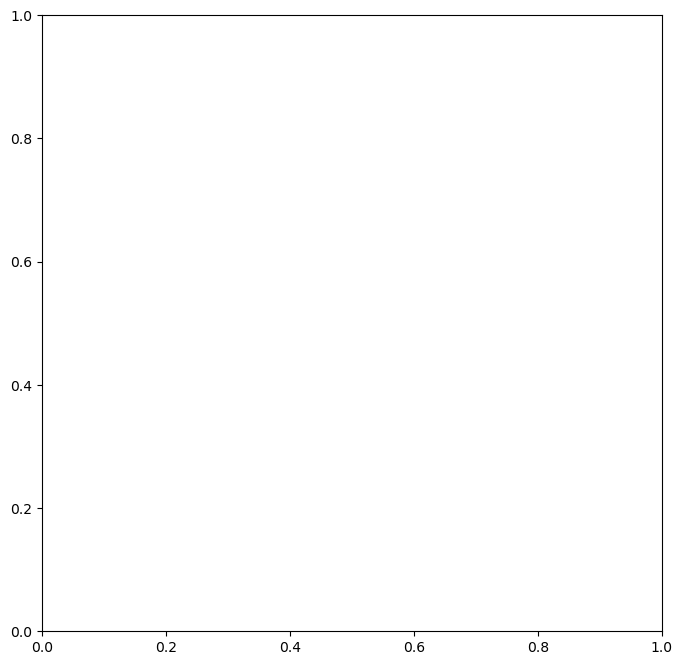

In [54]:

fig, ax = plt.subplots(figsize=(8, 8))


mu=6.866
sigma=2.260
skew=0.036

month_weights = skewed_gaussian_month_weights(mu, sigma, skew)


In [55]:
def slope_with_confidence_interval(x, y, n_boot=10_000, random_seed=42, lower_percentile=5, upper_percentile=95):
    """
    Calculate the slope of the best-fit line through the origin
    and a 90% bootstrap confidence interval for the slope.

    Parameters
    ----------
    x : array-like
        Independent variable data.
    y : array-like
        Dependent variable data.
    n_boot : int, optional
        Number of bootstrap samples. Default is 10,000.
    random_seed : int, optional
        Random seed for reproducibility. Default is 42.

    Returns
    -------
    slope : float
        Best-fit slope through the origin.
    """
    # Remove missing values
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Best-fit slope through the origin
    slope = np.sum(x * y) / np.sum(x**2)

    # Bootstrap slopes
    rng = np.random.default_rng(42)
    n_boot = 10_000

    bootstrap_slopes = np.empty(n_boot)

    for i in range(n_boot):
        indices = rng.integers(0, len(x), size=len(x))
        x_boot = x[indices]
        y_boot = y[indices]

        bootstrap_slopes[i] = (
            np.sum(x_boot * y_boot) /
            np.sum(x_boot**2)
        )

    # 5th and 95th percentile limits
    slope_lower, slope_upper = np.percentile(
        bootstrap_slopes, [lower_percentile, upper_percentile]
    )
    ci = (upper_percentile - lower_percentile)
    print(f"Slope: {slope:.3f}")
    print(
        f"{ci}% bootstrap confidence interval: "
        f"{slope_lower:.3f} to {slope_upper:.3f}"
    )
    return slope, slope_lower, slope_upper

In [56]:
weighted_energy_anomalies = []
weighted_sia_anomalies = []
model_names = []

for model in paleo_big_dict.keys():
    energy_data = np.dot(month_weights, paleo_big_dict[model]['anom_clim'][energy_for_analysis].data) 
    sia_data = np.min(paleo_big_dict[model]['anom_clim']['siconc'].data) / 1e14

    weighted_energy_anomalies.append(energy_data)
    weighted_sia_anomalies.append(sia_data)
    model_names.append(model)

    #print(np.min(big_dict[model]['anom_clim']['siconc']))

    energy_data = np.dot(month_weights, paleo_big_dict[model]['anom_clim'][energy_for_analysis].data) 
    #energy_data = np.dot(month_weights, big_dict[model]['anom_clim']['rlds'].data) + best_sw_weight * np.dot(month_weights, big_dict[model]['anom_clim']['rsds'].data)
    #energy_data = np.max(big_dict[model]['anom_clim'][energy_for_analysis].data)
    sia_data = np.min(paleo_big_dict[model]['anom_clim']['siconc'].data) / 1e14

    
    
print(model_names)
print(weighted_energy_anomalies)
print(weighted_sia_anomalies)

"""
['ACCESS-ESM1-5', 'CESM2', 'EC-Earth3', 'INM-CM4-8', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM1-F', 'NorESM2-LM', 'MMM']
[np.float64(2.210664415246274), np.float64(4.209376166631629), np.float64(5.571670330390003), np.float64(3.322180558967056), np.float64(3.8812716819943787), np.float64(2.773411739756073), np.float64(3.41131406224418), np.float64(4.25458768114349), np.float64(3.7801340512242043), np.float64(3.6538395276710545), np.float64(3.621383190568745), np.float64(3.6990757641670076)]
[np.float64(-0.9461397713722559), np.float64(-1.986983366777225), np.float64(-1.951534192217204), np.float64(-0.5107394467653628), np.float64(-0.9291961565309111), np.float64(-0.7494983731094695), np.float64(-0.8405469011587817), np.float64(-1.168386724907655), np.float64(-2.0203017457345083), np.float64(-0.7045492898277045), np.float64(-1.2905439637856304), np.float64(-1.1907654483806098)]
"""


['ACCESS-ESM1-5', 'CESM2', 'EC-Earth3', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'MMM']
[np.float64(2.210664415246274), np.float64(4.209376166631629), np.float64(5.571670330390003), np.float64(3.8812716819943787), np.float64(2.773411739756073), np.float64(3.41131406224418), np.float64(4.25458768114349), np.float64(3.7801340512242043), np.float64(3.621383190568745), np.float64(3.745979257688776)]
[np.float64(-0.9461397713722559), np.float64(-1.986983366777225), np.float64(-1.951534192217204), np.float64(-0.9291961565309111), np.float64(-0.7494983731094695), np.float64(-0.8405469011587817), np.float64(-1.168386724907655), np.float64(-2.0203017457345083), np.float64(-1.2905439637856304), np.float64(-1.3203479106215157)]


"\n['ACCESS-ESM1-5', 'CESM2', 'EC-Earth3', 'INM-CM4-8', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM1-F', 'NorESM2-LM', 'MMM']\n[np.float64(2.210664415246274), np.float64(4.209376166631629), np.float64(5.571670330390003), np.float64(3.322180558967056), np.float64(3.8812716819943787), np.float64(2.773411739756073), np.float64(3.41131406224418), np.float64(4.25458768114349), np.float64(3.7801340512242043), np.float64(3.6538395276710545), np.float64(3.621383190568745), np.float64(3.6990757641670076)]\n[np.float64(-0.9461397713722559), np.float64(-1.986983366777225), np.float64(-1.951534192217204), np.float64(-0.5107394467653628), np.float64(-0.9291961565309111), np.float64(-0.7494983731094695), np.float64(-0.8405469011587817), np.float64(-1.168386724907655), np.float64(-2.0203017457345083), np.float64(-0.7045492898277045), np.float64(-1.2905439637856304), np.float64(-1.1907654483806098)]\n"

Slope: -0.353
95% bootstrap confidence interval: -0.415 to -0.299


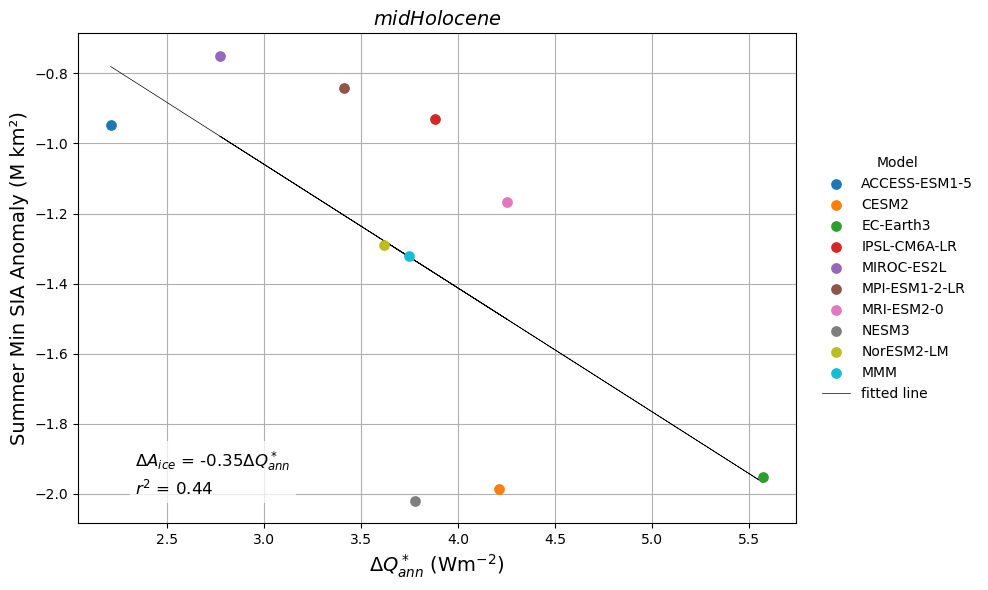

In [57]:

#add line of best fit, with intercept forced to zero

x = np.asarray(weighted_energy_anomalies)
y = np.asarray(weighted_sia_anomalies)


if len(model_names) != len(x):
    raise ValueError("Number of model names does not match the number of points")

cmap_name = 'tab10' if len(model_names) <= 10 else 'tab20'
model_colours = plt.get_cmap(cmap_name)(
    np.linspace(0, 1, len(model_names))
)

plt.figure(figsize=(10, 6))
for model, x_value, y_value, colour in zip(
    model_names, x, y, model_colours
):
    plt.scatter(
        x_value,
        y_value,
        color=colour,
        s=45,
        label=model,
        zorder=3
    )

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Best-fit slope through the origin
intercept = 0.0
slope = np.sum(x * y) / np.sum(x**2)

# Bootstrap slopes
rng = np.random.default_rng(42)
n_boot = 10_000

bootstrap_slopes = np.empty(n_boot)

for i in range(n_boot):
    indices = rng.integers(0, len(x), size=len(x))
    x_boot = x[indices]
    y_boot = y[indices]

    bootstrap_slopes[i] = (
        np.sum(x_boot * y_boot) /
        np.sum(x_boot**2)
    )

# 5th and 95th percentile limits
slope_lower, slope_upper = np.percentile(
    bootstrap_slopes, [2.5, 97.5]
)

print(f"Slope: {slope:.3f}")
print(
    f"95% bootstrap confidence interval: "
    f"{slope_lower:.3f} to {slope_upper:.3f}"
)

plt.plot(x, intercept + slope * x, 'k', linestyle='-', linewidth=0.5, label='fitted line')
plt.grid()
plt.xlabel('$\Delta Q_{{ann}}^*$ (Wm$^{-2}$)', fontsize=14)
plt.ylabel('Summer Min SIA Anomaly (M km²)', fontsize=14)
plt.title(r'$\mathit{midHolocene}$', fontsize=14)
#display the equation of the line and R-squared value
plt.text(
    0.08,
    0.15,
    f'$\Delta A_{{ice}}$ = {slope:.2f}$\Delta Q_{{ann}}^*$\n'
    f'$r^2$ = {r_value**2:.2f}',
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        boxstyle='square,pad=0.3',
        alpha=0.75
    )
)
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    title='Model',
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [58]:
def plot_overall_regression(obs_energy=None, obs_sia=None, extra_model_energy=None, extra_model_sia=None, xlim=None, ylim=None, save_name=None):    
    anom_colors = ['red']#, 'green', 'blue', 'orange']
    # model_markers = {
    #     'ACCESS-ESM1-5': 'x',
    #     'CESM2': 's',
    #     'IPSL-CM6A-LR': 'D',
    #     'MIROC-ES2L': '^',
    #     'NESM3': 'v',
    #     'MMM': '*',
    # }

    model_markers = {
        'ACCESS-ESM1-5': 'x',
        'CESM2': 's',
        'EC-Earth3': 'o',
        #'INM-CM4-8': 'D',
        'IPSL-CM6A-LR': 'D',
        'MIROC-ES2L': '^',
        'MPI-ESM1-2-LR': 'P',
        'MRI-ESM2-0': 'x',
        'NESM3': 'x',
        'NorESM2-LM': 'x',
        #'NorESM1-F': 'x',
        'MMM': '*',
    }

    energy_data_list = []
    sia_data_list = []

    fig, ax = plt.subplots(figsize=(10, 6))
    for big_dict, name, color in zip(anom_big_dict_list, anom_big_dict_names, anom_colors):
        for model in model_markers.keys():
            
                
            #print(np.sum(big_dict[model]['anom_clim']['total_energy']))
            #print(np.min(big_dict[model]['anom_clim']['siconc']))

            energy_data = np.dot(month_weights, big_dict[model]['anom_clim'][energy_for_analysis].data) 
            #energy_data = np.dot(month_weights, big_dict[model]['anom_clim']['rlds'].data) + best_sw_weight * np.dot(month_weights, big_dict[model]['anom_clim']['rsds'].data)
            #energy_data = np.max(big_dict[model]['anom_clim'][energy_for_analysis].data)
            sia_data = np.min(big_dict[model]['anom_clim']['siconc'].data) / 1e14
            
            
            
            if model == 'MMM':  # Exclude MMM  from the r2 analysis, but still plot it
                plt.scatter(
                    energy_data,
                    sia_data,
                    color=color,
                    marker=model_markers.get(model, 'o'),
                    s=180,
                    edgecolor='black',
                    linewidth=1.2,
                    #label=f'{name} {model}',
                    zorder=5,
                )
            else:
                plt.scatter(
                    energy_data, 
                    sia_data, 
                    color=color, 
                    marker=model_markers[model], 
                    #label=f'{name} {model}',
                    )
                energy_data_list.append(energy_data)
                sia_data_list.append(sia_data)

    # Convert to arrays
    energy_data_arr = np.asarray(energy_data_list, dtype=float)
    sia_data_arr = np.asarray(sia_data_list, dtype=float)

    # Get linear fit for the model data
    coefficients = np.polyfit(energy_data_arr, sia_data_arr, 1)
    slope = coefficients[0]
    intercept = coefficients[1]

    fix_intercept = True  # Set to True to force intercept to be zero

    if fix_intercept:
        #slope = np.dot(energy_data_arr, sia_data_arr) / np.dot(energy_data_arr, energy_data_arr)
        intercept = 0.0
        slope, slope_lower, slope_upper = slope_with_confidence_interval(energy_data_arr, sia_data_arr, n_boot=10_000, random_seed=42, lower_percentile=2.5, upper_percentile=97.5)
        
    linear_fit = np.poly1d([slope, intercept])

    x_fit = np.linspace(
        min(np.min(energy_data_arr), 0),
        np.max(energy_data_arr) * 1.2,
        100
    )

    y_fit = linear_fit(x_fit)

    # RMSE of model data against fitted regression line
    rmse_data = calc_rmse_against_fit(
        energy_data_arr,
        sia_data_arr,
        slope,
        intercept
    )

    if obs_energy is not None and obs_sia is not None:
        plt.scatter(
            obs_energy,
            obs_sia,
            marker='o',
            s=2.5,
            label='Observations',
            color='black'
        )

        r2_obs = np.corrcoef(obs_energy, obs_sia)[0, 1] ** 2

        rmse_obs = calc_rmse_against_fit(
            obs_energy,
            obs_sia,
            slope,
            intercept
        )

    if extra_model_energy is not None and extra_model_sia is not None:
        plt.scatter(
            extra_model_energy,
            extra_model_sia,
            marker='X',
            s=100,
            label='Extra Model',
            color='purple'
        )

        r2_extra = np.corrcoef(extra_model_energy, extra_model_sia)[0, 1] ** 2

        rmse_extra = calc_rmse_against_fit(
            extra_model_energy,
            extra_model_sia,
            slope,
            intercept
        )

    plt.plot(x_fit, y_fit, color='black', linestyle='--', label='Linear Fit')
    plt.xlabel('$\Delta Q*$ (Wm$^{-2}$)', fontsize=14)
    plt.ylabel('Minimum SIA Anomaly (M km²)', fontsize=14)
    #plt.title('Weighted Energy Budget Anomaly vs Minimum SIA Anomaly')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
    #put legend outside of plot
    #plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    if xlim is not None:
        plt.xlim(xlim)
    else:
        plt.xlim(0, max(energy_data_list) * 1.1)
    if ylim is not None:
        plt.ylim(ylim)
    plt.grid()

    # ------------------------------------------------------------------
    # Custom legends
    # ------------------------------------------------------------------

    # Shape legend: one marker per model
    shape_handles = []

    for model, marker in model_markers.items():
        if model == 'MMM':
            handle = Line2D(
                [0], [0],
                marker=marker,
                color='none',
                markerfacecolor='grey',
                markeredgecolor='black',
                markeredgewidth=1.2,
                markersize=14,
                linestyle='None',
                label=model
            )
        else:
            handle = Line2D(
                [0], [0],
                marker=marker,
                color='grey',
                markerfacecolor='grey',
                markeredgecolor='grey',
                markersize=8,
                linestyle='None',
                label=model
            )

        shape_handles.append(handle)

    # Colour legend: one colour per anomaly set
    colour_handles = [
        Line2D(
            [0], [0],
            marker='o',
            color='none',
            markerfacecolor=color,
            markeredgecolor='black',
            markersize=8,
            linestyle='None',
            label=name
        )
        for name, color in zip(anom_big_dict_names, anom_colors)
    ]

    # Regression legend
    line_handles = [
        Line2D(
            [0], [0],
            color='black',
            linestyle='--',
            label='Linear fit'
        ),
        Line2D(
            [0], [0],
            color='none',
            marker='o',
            markerfacecolor='black',
            markersize=2,
            label='Observations / Reanalysis'
        )
    ]

    # First legend: model shapes
    legend1 = ax.legend(
        handles=shape_handles,
        title='Model',
        fontsize=12,
        loc='center left',
        bbox_to_anchor=(1.02, 0.70),
        frameon=False
    )

    # Add first legend manually so it is not overwritten
    ax.add_artist(legend1)

    # Second legend: colours
    legend2 = ax.legend(
        handles=colour_handles + line_handles,
        title='Experiment',
        loc='center left',
        bbox_to_anchor=(1.02, 0.30),
        frameon=False
    )

    #set ticklabel size on both axes
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()
    plt.show()

    r2 = np.corrcoef(energy_data_arr, sia_data_arr)[0, 1] ** 2

    print(f'R² between energy data and SIA data: {r2:.3f}')
    print(f'Linear regression coefficients: slope = {slope:.3f}, intercept = {intercept:.3f}')
    print(f'RMSE of model data against linear regression: {rmse_data:.3f} M km²')

    if obs_energy is not None and obs_sia is not None:
        print(f'R² between weighted energy data and observed SIA anomaly: {r2_obs:.5f}')
        print(f'RMSE of observed SIA anomaly against model regression: {rmse_obs:.3f} M km²')

    if extra_model_energy is not None and extra_model_sia is not None:
        print(f'R² between weighted energy data and extra model SIA anomaly: {r2_extra:.3f}')
        print(f'RMSE of extra model SIA anomaly against model regression: {rmse_extra:.3f} M km²')
    if save_name is not None:
        fig.savefig(
        f'{plot_path}{save_name}',
        bbox_inches='tight',
        )
    return slope, intercept, r2


Slope: -0.353
95.0% bootstrap confidence interval: -0.422 to -0.290


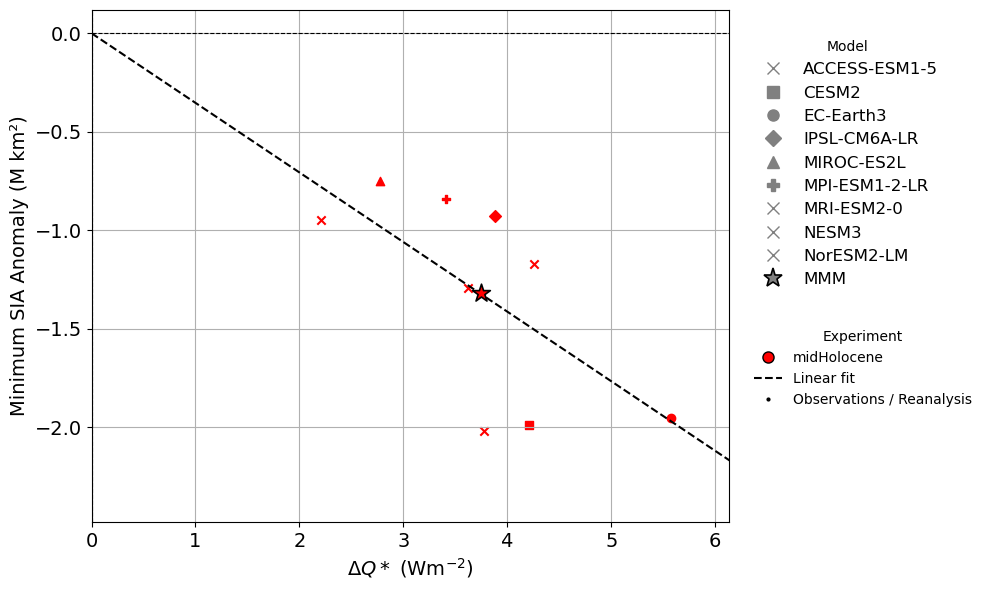

R² between energy data and SIA data: 0.438
Linear regression coefficients: slope = -0.353, intercept = 0.000
RMSE of model data against linear regression: 0.371 M km²


In [59]:
slope, intercept, r2 = plot_overall_regression()